In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
import keras
import numpy as np

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\extended_flower_morphometrics (1).csv")
df=data.copy()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   sepal_length_cm    200000 non-null  float64
 1   sepal_width_cm     200000 non-null  float64
 2   petal_length_cm    200000 non-null  float64
 3   petal_width_cm     200000 non-null  float64
 4   stem_thickness_mm  200000 non-null  float64
 5   petal_density_pct  200000 non-null  float64
 6   chlorophyll_index  200000 non-null  float64
 7   native_altitude_m  200000 non-null  float64
 8   species            200000 non-null  object 
dtypes: float64(8), object(1)
memory usage: 13.7+ MB


In [4]:
#sns.pairplot(data=df,hue='species')

In [5]:
df.species.unique()

array(['Rose', 'Iris Versicolor', 'Orchid', 'Iris Setosa', 'Sunflower'],
      dtype=object)

In [6]:
#data.head(5)

In [7]:
df.head(5)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m,species
0,4.317614,3.028292,6.092543,3.166156,5.063025,63.558150,55.913100,886.568622,Rose
1,5.531122,3.887679,5.497682,2.374855,4.656235,52.368783,26.383116,247.206553,Iris Versicolor
2,5.908407,2.576321,6.264473,1.785481,5.893707,36.056153,61.562376,1197.921681,Orchid
3,6.855284,2.764075,4.606390,1.175031,4.854951,55.623467,38.671083,940.401196,Iris Versicolor
4,5.412124,3.691987,1.800383,0.221225,2.528513,60.218904,34.674831,679.473136,Iris Setosa


In [9]:
#type1

In [10]:
type1=df['species'].unique()

In [11]:
type1=type1.astype(str)

In [12]:
from sklearn.preprocessing import OrdinalEncoder,StandardScaler


In [13]:
ord=OrdinalEncoder(categories=[type1])

In [14]:
df['species']=ord.fit_transform(df[['species']]).astype(int)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

In [16]:
#ord.transform(df[['species']])

In [17]:
std=StandardScaler()

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x=df.drop(columns='species')
y=df['species']

In [20]:
x=pd.DataFrame(std.fit_transform(x),columns=x.columns)

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [52]:
tensorflow.keras.callbacks.Callback()

In [83]:
model=keras.Sequential([
    keras.layers.Dense(1000,input_shape=(8,),activation='relu'),
    keras.layers.Dense(700,activation='relu'),
    keras.layers.Dense(500,activation='relu'),
    keras.layers.Dense(5,activation='sigmoid')

])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5,batch_size=5000,validation_data=(x_test,y_test))

Epoch 1/5


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.7652 - loss: 0.5808 - val_accuracy: 0.8131 - val_loss: 0.4219
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.8145 - loss: 0.4118 - val_accuracy: 0.8184 - val_loss: 0.4056
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.8200 - loss: 0.4011 - val_accuracy: 0.8196 - val_loss: 0.4024
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.8211 - loss: 0.3986 - val_accuracy: 0.8207 - val_loss: 0.3994
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.8219 - loss: 0.3969 - val_accuracy: 0.8204 - val_loss: 0.3999


In [75]:
model.evaluate(x_test,y_test)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8217 - loss: 0.3992


[0.39919915795326233, 0.8216500282287598]

In [55]:
x_train.shape

(160000, 8)

In [56]:
df.shape

(200000, 9)

In [61]:
x_test

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,stem_thickness_mm,petal_density_pct,chlorophyll_index,native_altitude_m
177150,-0.589978,0.877058,-0.166267,-0.061910,-0.136943,1.836635,1.056477,0.743617
110173,-1.124300,-0.373012,-0.351118,0.247269,-0.238975,-0.007203,1.429324,0.269087
15383,-0.153972,-0.490781,-0.375246,-0.336646,-0.590084,0.233480,-0.088997,0.678748
117329,-0.862685,-0.029778,0.398043,0.369043,-0.050997,2.734260,-1.275597,-0.277470
50041,-0.665878,-0.860011,-0.053276,-0.437855,-0.009014,0.060594,0.722576,-0.881708
...,...,...,...,...,...,...,...,...
23294,-0.332046,-1.434950,-0.555371,-0.628654,-0.514414,-0.306298,0.247138,0.786601
51723,0.089646,0.304570,-0.478206,-0.097540,-0.736464,1.969664,0.850450,0.412047
129589,-0.871647,0.055481,-0.115283,0.752543,0.123795,1.725368,0.499459,-0.496918
181737,2.604098,0.705537,1.588523,1.125601,1.842543,-1.034100,0.786445,-0.047390


In [67]:
np.argmax(model.predict(np.array([[-0.589978,0.877058,-0.166267,-0.061910,-0.136943,1.836635,1.056477,0.743617]])))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


np.int64(0)

In [57]:
y_pre=model.predict(x_test)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [58]:
y_true=[]
for i in range(0,40000):
    a=np.argmax(y_pre[i])
    y_true.append(a)

In [59]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_true)

Text(0.5, 23.52222222222222, 'predicted')

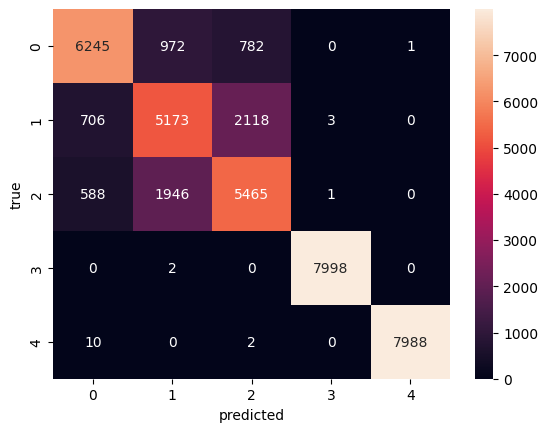

In [60]:
sns.heatmap(cm,annot=True,fmt='d')
plt.ylabel("true")
plt.xlabel('predicted')

In [68]:
y_test

177150    0
110173    0
15383     1
117329    0
50041     1
         ..
23294     1
51723     0
129589    0
181737    4
119998    0
Name: species, Length: 40000, dtype: int64